CPU x Memória RAM

Selecione os arquivos 'metrics_docker_stats_mqttsn.csv' e 'metrics_docker_stats_p4ssn.csv':


Saving metrics_docker_stats_mqttsn.csv to metrics_docker_stats_mqttsn.csv
Saving metrics_docker_stats_p4ssn.csv to metrics_docker_stats_p4ssn.csv


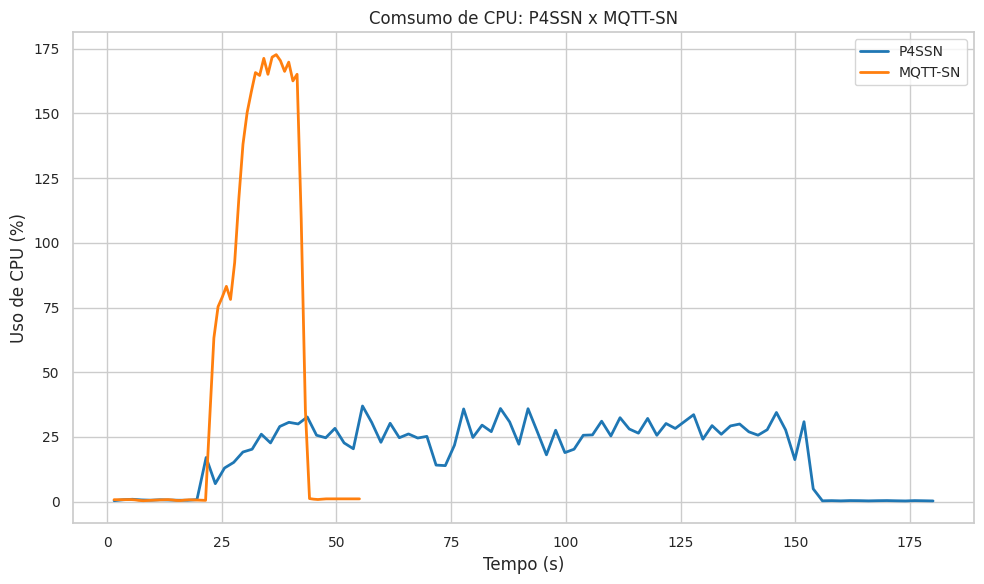

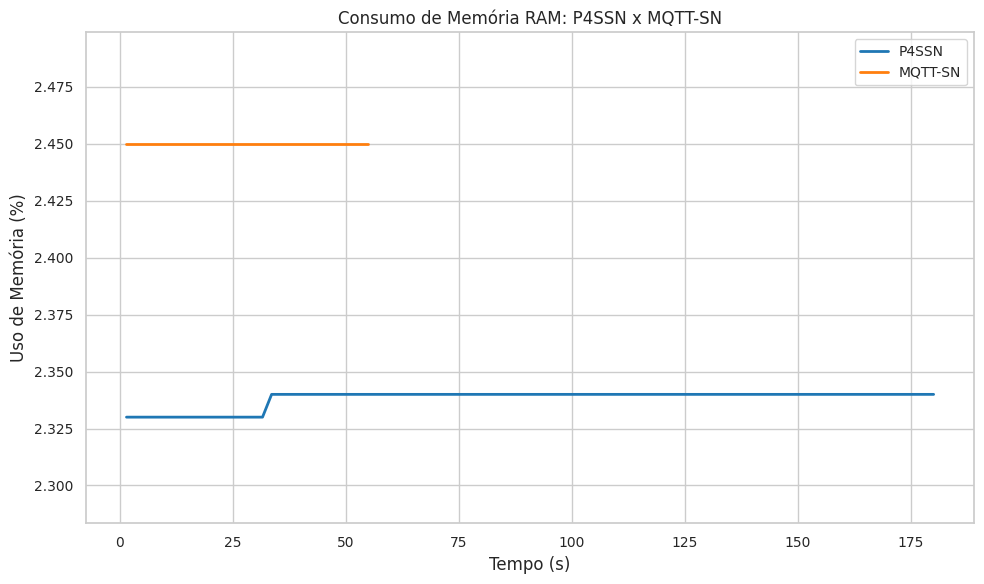


Iniciando download dos arquivos EPS...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files
import io

# 1. Upload dos arquivos
print("Selecione os arquivos 'metrics_docker_stats_mqttsn.csv' e 'metrics_docker_stats_p4ssn.csv':")
uploaded = files.upload()

# 2. Carregamento dos DataFrames
# Ajuste automático caso os nomes dos arquivos variem levemente no upload
df_mq = pd.read_csv(io.BytesIO(uploaded['metrics_docker_stats_mqttsn.csv']))
df_p4 = pd.read_csv(io.BytesIO(uploaded['metrics_docker_stats_p4ssn.csv']))

# 3. Configurações de Estilo para Publicação
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

# --- GRÁFICO 1: COMPARATIVO DE CPU ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_p4, x='relative_time', y='cpu_percent',
             label='P4SSN', color='#1f77b4', linewidth=2)
sns.lineplot(data=df_mq, x='relative_time', y='cpu_percent',
             label='MQTT-SN', color='#ff7f0e', linewidth=2)

plt.title('Consumo de CPU: P4SSN x MQTT-SN')
plt.xlabel('Tempo (s)')
plt.ylabel('Uso de CPU (%)')
plt.legend(loc='upper right')
plt.tight_layout()

# Salvar em EPS
plt.savefig('cpu.eps', format='eps', dpi=300)
plt.show()

# --- GRÁFICO 2: COMPARATIVO DE MEMÓRIA ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_p4, x='relative_time', y='mem_percent',
             label='P4SSN', color='#1f77b4', linewidth=2)
sns.lineplot(data=df_mq, x='relative_time', y='mem_percent',
             label='MQTT-SN', color='#ff7f0e', linewidth=2)

plt.title('Consumo de Memória RAM: P4SSN x MQTT-SN')
plt.xlabel('Tempo (s)')
plt.ylabel('Uso de Memória (%)')

# Ajuste do eixo Y para destacar as variações sutis de RAM
y_min = min(df_mq['mem_percent'].min(), df_p4['mem_percent'].min()) * 0.98
y_max = max(df_mq['mem_percent'].max(), df_p4['mem_percent'].max()) * 1.02
plt.ylim(y_min, y_max)

plt.legend(loc='upper right')
plt.tight_layout()

# Salvar em EPS
plt.savefig('memory.eps', format='eps', dpi=300)
plt.show()

# 4. Download automático dos arquivos EPS gerados
print("\nIniciando download dos arquivos EPS...")
files.download('cpu.eps')
files.download('memory.eps')

### Quantidade de Mensagens

/tmp/ipykernel_4135/2039492860.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['P4SSN', 'MQTT-SN'])


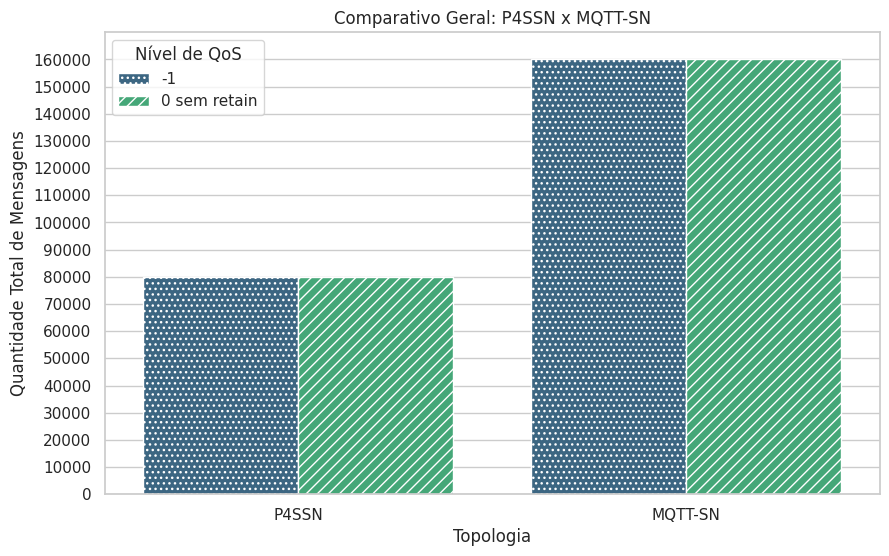

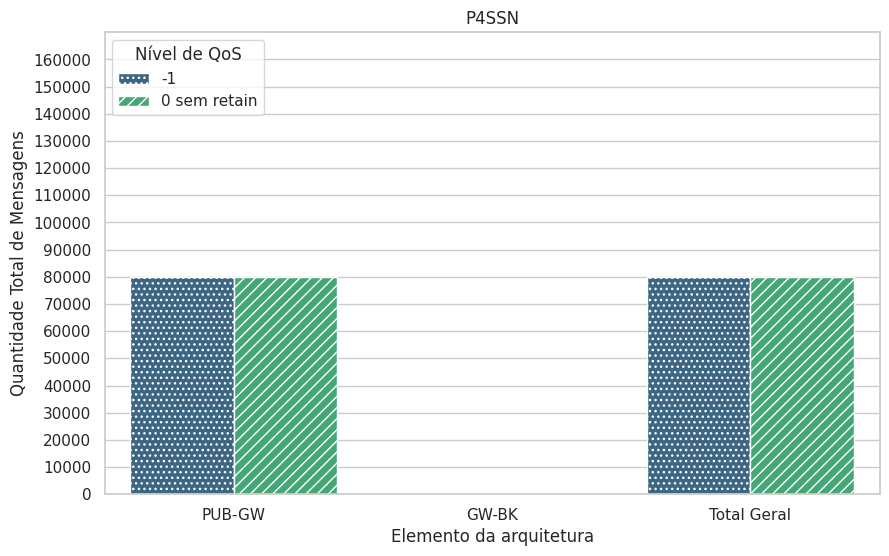

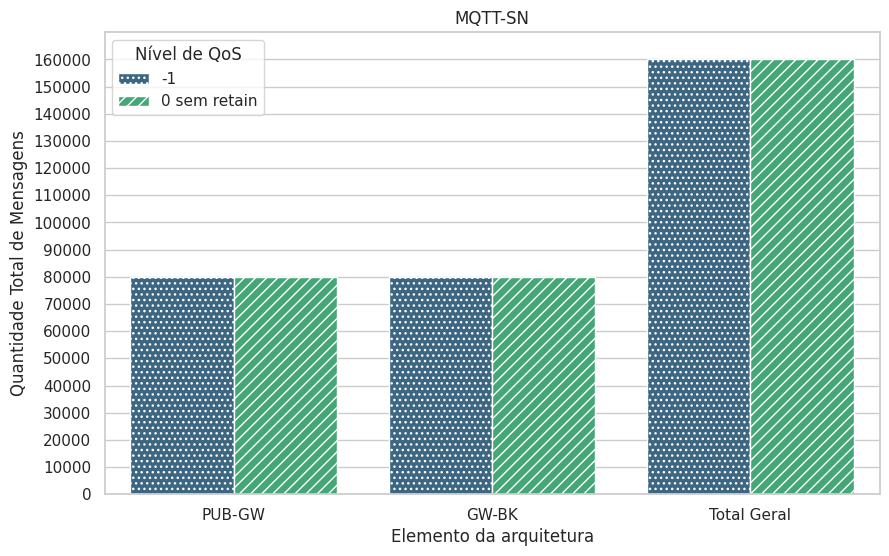

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
import numpy as np
import matplotlib.patches as mpatches

# 1. Dados e Preparação
csv_data = """topologia,qos,pub_gw,gw_bk,qtd_msg
p4ssn,-1,80000,0,80000
p4ssn,0 sem retain,80000,0,80000
mqttsn,-1,80000,80000,160000
mqttsn,0 sem retain,80000,80000,160000"""

df = pd.read_csv(io.StringIO(csv_data))

# 2. Transformação dos dados
df_elements = df.melt(id_vars=['topologia', 'qos'],
                      value_vars=['pub_gw', 'gw_bk'],
                      var_name='Elemento da arquitetura',
                      value_name='Quantidade Total de Mensagens')

df_total = df[['topologia', 'qos', 'qtd_msg']].copy()
df_total.rename(columns={'qtd_msg': 'Quantidade Total de Mensagens'}, inplace=True)
df_total['Elemento da arquitetura'] = 'Total Geral'

df_final = pd.concat([df_elements, df_total], ignore_index=True)
df_final.rename(columns={'topologia': 'Topologia'}, inplace=True)

df.rename(columns={'topologia': 'Topologia', 'qtd_msg': 'Quantidade Total de Mensagens'}, inplace=True)

mapeamento = {'pub_gw': 'PUB-GW', 'gw_bk': 'GW-BK'}
df_final['Elemento da arquitetura'] = df_final['Elemento da arquitetura'].replace(mapeamento)

# 3. Função de Estilo - Removido o contorno preto
def aplicar_estilo_e_legenda(ax, title_legend='Nível de QoS'):
    # Ordem: 1ª barra (pontos), 2ª barra (hachuras)
    patterns = ['...', '///']

    # Coletamos os dados da legenda original antes de removê-la
    handles, labels = ax.get_legend_handles_labels()
    palette_colors = [h.get_facecolor() for h in handles]

    # Percorremos os containers (grupos de barras por QoS)
    for i, container in enumerate(ax.containers):
        hatch_style = patterns[i % len(patterns)]
        for bar in container:
            bar.set_hatch(hatch_style)
            # REMOVIDO: bar.set_edgecolor('black') para tirar o contorno

    # Recriar a legenda com as texturas (sem contorno também)
    patches = [mpatches.Patch(facecolor=palette_colors[i],
                             hatch=patterns[i],
                             label=labels[i])
               for i in range(len(labels))]
    ax.legend(handles=patches, title=title_legend, loc='upper left')

# Configurações de Estilo
sns.set_theme(style="whitegrid")
palette = "viridis"
ticks_k = np.arange(0, 170000, 10000)

# --- GRÁFICO 1: Comparativo Geral ---
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=df, x='Topologia', y='Quantidade Total de Mensagens', hue='qos', palette=palette)
ax1.set_xticklabels(['P4SSN', 'MQTT-SN'])
plt.yticks(ticks_k)
plt.ylim(0, 170000)
aplicar_estilo_e_legenda(ax1)
plt.title('Comparativo Geral: P4SSN x MQTT-SN')
plt.savefig("grafico_comparativo_geral.eps", format='eps', bbox_inches='tight')
plt.show()

# --- GRÁFICO 2: Detalhe P4SSN ---
plt.figure(figsize=(10, 6))
df_p4 = df_final[df_final['Topologia'] == 'p4ssn']
ax2 = sns.barplot(data=df_p4, x='Elemento da arquitetura', y='Quantidade Total de Mensagens', hue='qos', palette=palette)
plt.yticks(ticks_k)
plt.ylim(0, 170000)
aplicar_estilo_e_legenda(ax2)
plt.title('P4SSN')
plt.savefig("grafico_p4ssn_total.eps", format='eps', bbox_inches='tight')
plt.show()

# --- GRÁFICO 3: Detalhe MQTT-SN ---
plt.figure(figsize=(10, 6))
df_mqtt = df_final[df_final['Topologia'] == 'mqttsn']
ax3 = sns.barplot(data=df_mqtt, x='Elemento da arquitetura', y='Quantidade Total de Mensagens', hue='qos', palette=palette)
plt.yticks(ticks_k)
plt.ylim(0, 170000)
aplicar_estilo_e_legenda(ax3)
plt.title('MQTT-SN')
plt.savefig("grafico_mqttsn_total.eps", format='eps', bbox_inches='tight')
plt.show()